In [1]:
import numpy as np
import torch
import random
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import shap
from lime.lime_tabular import LimeTabularExplainer
from rule_of_thumb import RuleOfThumb
from fair_PCA import apply_fair_PCA_to_dataset
import time

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
def set_seeds(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds()

In [3]:
OBLIVIATE_FEATURE = '$\mathbf{Age}$'
filename_prefix = 'Age'

In [4]:
FIGSIZE = (6,5)

In [5]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Pregnancies', 'Glucose', 'Blood\nPressure', 'Skin\nThickness', 'Insulin', 'BMI', 'Diabetes\nPedigree Func.', '$\mathbf{Age}$', 'Outcome']
diabetes_df = pd.read_csv(url, names=column_names)

x_data = diabetes_df.iloc[:, :-1].values
y_data = diabetes_df.iloc[:, -1].values
z_data = diabetes_df[OBLIVIATE_FEATURE].values > np.mean(diabetes_df[OBLIVIATE_FEATURE].values) #33.24

x_train, x_test, y_train, y_test, z_train, z_test = train_test_split(
    x_data, 
    y_data,
    z_data,
    test_size=0.2, 
    random_state=0
)


In [6]:
bb_model = apply_fair_PCA_to_dataset((x_train, y_train, z_train), x_train.shape[1]-2)

In [7]:
y_pred_train = bb_model.predict(x_train)
y_pred_test = bb_model.predict(x_test)

train_accuracy = np.mean(y_pred_train == y_train)
test_accuracy = np.mean(y_pred_test == y_test)
print(f"Model Train Accuracy: {train_accuracy}")
print(f"Model Test Accuracy: {test_accuracy}")

rot_init_start = time.time()
rot = RuleOfThumb(y_pred_train, x_train)
rot_init_end = time.time()
rot_preds_train = rot._explainer_model.predict(torch.from_numpy(x_train).to(torch.float)).detach().numpy()
rot_preds_test = rot._explainer_model.predict(torch.from_numpy(x_test).to(torch.float)).detach().numpy()

train_accuracy = np.mean(rot_preds_train == y_train)
test_accuracy = np.mean(rot_preds_test == y_test)
print(f"RoT Train Accuracy: {train_accuracy}")
print(f"RoT Test Accuracy: {test_accuracy}")


Model Train Accuracy: 0.750814332247557
Model Test Accuracy: 0.7857142857142857
		Epoch: 1, Loss: 0.1466888040304184
		Epoch: 1, Loss: 0.0835932195186615
		Epoch: 201, Loss: 0.06475821882486343
		Epoch: 401, Loss: 0.06347348541021347
		Epoch: 601, Loss: 0.06419441848993301
		Epoch: 801, Loss: 0.06561301648616791
		Epoch: 1001, Loss: 0.06749607622623444
		Epoch: 1201, Loss: 0.062365733087062836
		Epoch: 1401, Loss: 0.06154428794980049
RoT Train Accuracy: 0.6856677524429967
RoT Test Accuracy: 0.7142857142857143


In [8]:
rot_model = rot

feature_names = column_names[:-1]



In [9]:
rot_start = 0
rot_end = 0
shap_start = 0
shap_middle = 0
shap_end = 0
lime_start = 0
lime_middle = 0
lime_end = 0

def generate_shap_beeswarm_plot(model, dataset, feature_names):
    """
    Generate SHAP beeswarm plot using matplotlib
    """
    global shap_start
    global shap_middle
    global shap_end
    shap_start = time.time()
    explainer = shap.KernelExplainer(model.predict_proba, dataset)
    shap_middle = time.time()
    shap_values = explainer.shap_values(dataset)[0]
    shap_end = time.time()
    # print(f'{shap_values.shape=}')
    # shap_values = shap_values[:,:,1]
    plt.clf()
    shap.summary_plot(shap_values, dataset, feature_names=feature_names, show=False, plot_size=FIGSIZE)
    plt.xlabel("SHAP importance (Contribution to Model Output)")
    plt.ylim(-0.6,7.6)
    plt.tight_layout()
    return plt

def generate_rot_beeswarm_plot(model, dataset, feature_names):
    """
    Generate RoT beeswarm plot using matplotlib
    """
    global rot_start
    global rot_end
    rot_start = time.time()
    rot_exps = rot_model.get_explanation(dataset)
    rot_end = time.time()
    print(f'{rot_exps.shape=}')
    # rot_exps = 1 / (1 + np.exp(-rot_exps))  # Convert each value to a probability using sigmoid
    plt.clf()
    shap.summary_plot(rot_exps, dataset, feature_names=feature_names, show=False, color=plt.get_cmap("jet"), cmap="jet", plot_size=FIGSIZE)
    plt.xlabel("RoT importance (Contribution to Model Output)")
    plt.ylim(-0.6,7.6)
    plt.tight_layout()
    return plt

def generate_lime_beeswarm_plot(model, dataset, feature_names, class_idx=1):
    """
    Generate LIME beeswarm plot using matplotlib.
    
    Parameters
    ----------
    model : object
        A fitted model with a predict_proba method.
    dataset : np.ndarray
        Dataset to explain (2D array, shape: [n_samples, n_features]).
    feature_names : list
        Names of the features (len(feature_names) == n_features).
    class_idx : int, optional
        Index of the class for which explanations are generated (default=1).
    """
    global lime_start
    global lime_middle
    global lime_end
    lime_start = time.time()
    explainer = LimeTabularExplainer(
        training_data=dataset,
        feature_names=feature_names,
        class_names=[str(i) for i in range(model.predict_proba(dataset[:1]).shape[1])],
        mode="classification"
    )
    n_samples, n_features = dataset.shape
    lime_values = np.zeros((n_samples, n_features))
    lime_middle = time.time()
    for i in range(n_samples):
        exp = explainer.explain_instance(dataset[i], model.predict_proba, num_features=n_features)
        local_exp = dict(exp.as_map()[class_idx])
        for j in range(n_features):
            lime_values[i, j] = local_exp.get(j, 0.0)
    lime_end = time.time()
    plt.clf()
    shap.summary_plot(lime_values, dataset, feature_names=feature_names, show=False, color=plt.get_cmap("winter"), cmap='winter', plot_size=FIGSIZE)
    plt.xlabel("LIME importance (Contribution to Model Output)")
    plt.ylim(-0.6,7.6)
    plt.tight_layout()
    return plt


rot_exps.shape=(154, 8)


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


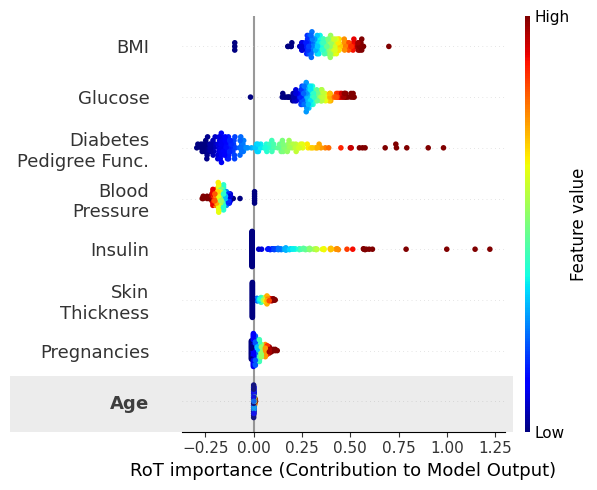

In [10]:

plt.clf()
pl = generate_rot_beeswarm_plot(bb_model, x_test, feature_names)
ax = plt.gca()
# Rectangle in data coordinates, but drawn over everything
rect = Rectangle(
    (-1.26, -0.6), 2.6, 1.1,     # x, y, width, height
    facecolor='gray',
    alpha=0.15,
    clip_on=False,            # allows it to extend beyond plot area
    zorder=10                 # draw on top
)
ax.add_patch(rect)
pl.savefig(f'./PLOTS/{filename_prefix}-rotswarm.pdf', dpi=300)
plt.show()


Using 154 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/154 [00:00<?, ?it/s]

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


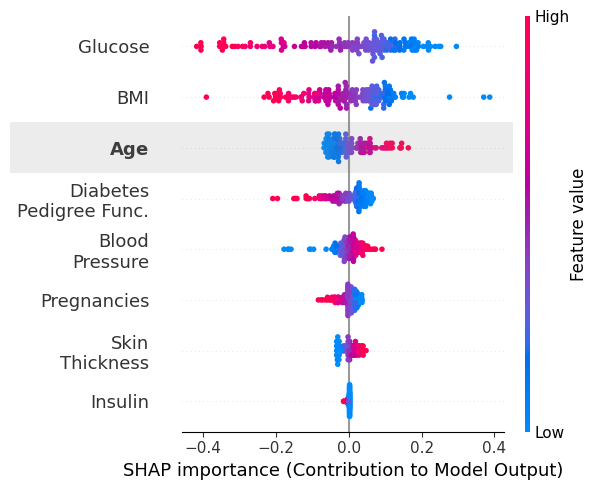

In [11]:
plt.clf()
pl = generate_shap_beeswarm_plot(bb_model, x_test, feature_names)
ax = plt.gca()
# Rectangle in data coordinates, but drawn over everything
rect = Rectangle(
    (-0.93, 4.5), 1.38, 1.01,     # x, y, width, height
    facecolor='gray',
    alpha=0.15,
    clip_on=False,            # allows it to extend beyond plot area
    zorder=10                 # draw on top
)
ax.add_patch(rect)

pl.savefig(f'./PLOTS/{filename_prefix}-shapswarm.pdf', dpi=300)
plt.show()

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


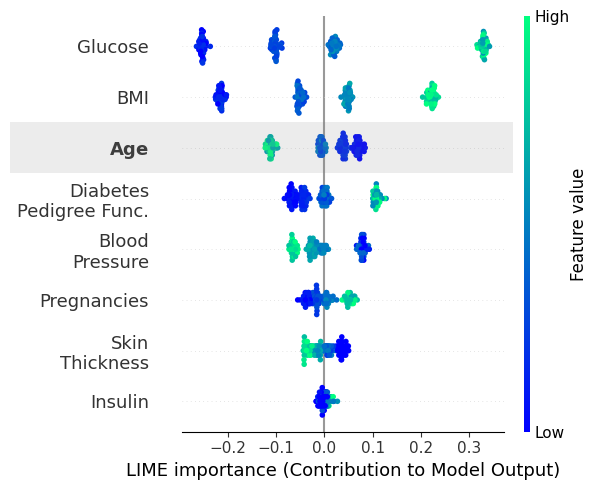

In [12]:
plt.clf()
pl = generate_lime_beeswarm_plot(bb_model, x_test, feature_names)
ax = plt.gca()
# Rectangle in data coordinates, but drawn over everything
rect = Rectangle(
    (-0.65, 4.5), 1.04, 1.01,     # x, y, width, height
    facecolor='gray',
    alpha=0.15,
    clip_on=False,            # allows it to extend beyond plot area
    zorder=10                 # draw on top
)
ax.add_patch(rect)

pl.savefig(f'./PLOTS/{filename_prefix}-limeswarm.pdf', dpi=300)

plt.show()

In [13]:
rot_init = rot_init_end - rot_init_start
rot_total = (rot_init_end - rot_init_start) + (rot_end - rot_start)

shap_init = shap_middle - shap_start
shap_total = shap_end - shap_start

lime_init = lime_middle - lime_start
lime_total = lime_end - lime_start


In [14]:
print(f'{rot_init=}')
print(f'{rot_total=}')
print(f'{shap_init=}')
print(f'{shap_total=}')
print(f'{lime_init=}')
print(f'{lime_total=}')

rot_init=1.0310442447662354
rot_total=1.031313180923462
shap_init=0.0006506443023681641
shap_total=9.323766708374023
lime_init=0.0021772384643554688
lime_total=1.307981252670288


In [15]:
print(f'speedup over shap = {shap_total / rot_total}')
print(f'speedup over lime = {lime_total / rot_total}')

speedup over shap = 9.040674434147448
speedup over lime = 1.2682677549986234
